# A simple regression problem: how many ice creams will we sell?

**UWE Bristol · Introduction to Machine Learning**

This notebook works through one small regression problem from start to finish. At every step we
stop and ask: *what are we trying to do, and what does this result mean for the problem?*

Run each cell in order with **Shift + Enter**, and read the text above each cell before running it.

## 1. The problem

Sam runs an ice-cream van on Bristol's harbourside. Every morning Sam has to decide how many ice
creams to load into the van's freezer:

- load **too few**, and Sam sells out by lunchtime and loses sales;
- load **too many**, and the extra stock is wasted or has to be stored.

Sam has noticed that hotter days are busier, and has kept a record of the temperature and the number
of ice creams sold on 24 days last summer.

**Sam's question:** *if I know tomorrow's forecast temperature, how many ice creams should I expect to sell?*

### Turning this into a machine learning problem

- The thing we want to predict, the **label** (or target), is the **number of ice creams sold**.
- The information we use to predict it, the **feature**, is the **temperature in °C**.
- The label is a **number** on a scale (not a category like "busy" or "quiet"), so this is a
  **regression** problem.
- We have past days where we know both the temperature and the answer, so this is **supervised learning**.

We will use the simplest regression model, **linear regression**, which fits a straight line through the data.

## 2. Setting up

We import the tools we need. Each line has a comment explaining what it is for.

In [1]:
# pandas: holds our data in a table
import pandas as pd
# numpy: number crunching
import numpy as np
# matplotlib: charts
import matplotlib.pyplot as plt

# scikit-learn: splitting the data, the model, and the performance measures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Chart style and colours used throughout
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
POINT_COLOUR = "#1D1C21"   # dark grey: training days
TEST_COLOUR = "#eb6834"    # orange: test days
LINE_COLOUR = "#2a78d6"    # blue: the model's line

## 3. Sam's data

Here are Sam's 24 days, typed straight into the notebook so you can see every value. In a real
project this would usually come from a spreadsheet or CSV file, loaded with `pd.read_csv`.

In [2]:
temperature = [14, 21, 23, 13, 15, 29, 13, 14, 29, 23, 19, 21,
               24, 17, 14, 26, 24, 21, 27, 22, 30, 16, 22, 21]
ice_creams  = [49, 118, 138, 50, 62, 192, 75, 69, 183, 149, 121, 124,
               159, 109, 70, 158, 156, 131, 189, 121, 192, 78, 115, 130]

df = pd.DataFrame({"temperature": temperature, "ice_creams": ice_creams})

print("Number of days:", len(df))
df.head(8)

Number of days: 24


,temperature,ice_creams
0,14,49
1,21,118
2,23,138
3,13,50
4,15,62
5,29,192
6,13,75
7,14,69


Each **row** is one day. The `temperature` column is the feature and `ice_creams` is the label.

### A quick summary

Before modelling, it is worth checking the basic numbers: how hot did it get, and how many ice creams
were sold on a typical day?

In [3]:
df.describe().round(1)

,temperature,ice_creams
count,24.0,24.0
mean,20.8,122.4
std,5.3,45.2
min,13.0,49.0
25%,15.8,77.2
50%,21.0,122.5
75%,24.0,156.5
max,30.0,192.0


Temperatures range from 13°C to 30°C, and sales range from about 50 to about 190 ice creams a day.
There are no missing values: every day has both a temperature and a sales figure, so no cleaning is
needed. (With real data, this is where we would deal with gaps, typing mistakes or duplicate days.)

## 4. Looking at the data

A scatter plot shows each day as a dot. If hotter days really are busier, the dots should rise from
left to right.

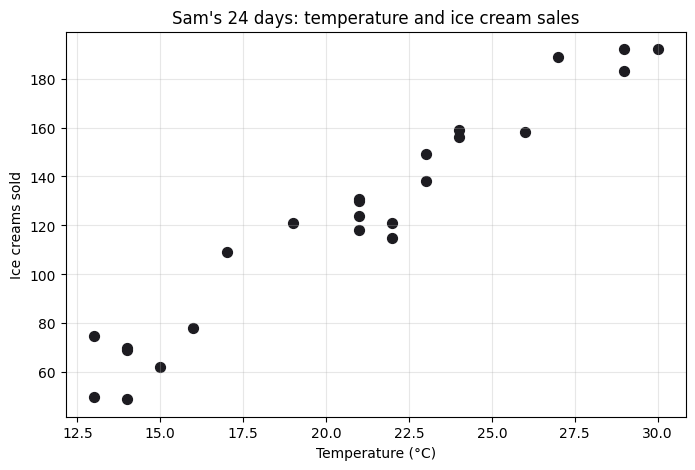

In [4]:
plt.scatter(df["temperature"], df["ice_creams"], color=POINT_COLOUR, s=50)
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice creams sold")
plt.title("Sam's 24 days: temperature and ice cream sales")
plt.show()

**What does this tell us about the problem?** The dots rise steadily from left to right in a roughly
straight band. So:

- hotter days do sell more ice creams, as Sam suspected;
- the pattern looks like a **straight line**, so linear regression is a sensible choice;
- the dots are not perfectly on a line. Two days with the same temperature can have different sales
  (other things, such as whether it is a weekend, also matter). So even a good model will not be exact.

We can put a number on how closely the two go together with the **correlation**, which runs from −1 to +1:

In [5]:
print("Correlation between temperature and sales:", round(df["temperature"].corr(df["ice_creams"]), 3))

Correlation between temperature and sales: 0.973


A value this close to +1 means a strong, positive, straight-line relationship.

## 5. Splitting the data: training set and test set

We want to know how well our model will work on **future** days, not just the days it has already seen.
So we hide some of the days away:

- the **training set** (18 days) is used to fit the line;
- the **test set** (6 days) is kept back and only used at the end, to check the predictions against
  days the model has never seen, just like tomorrow.

`random_state=42` means the split is the same every time you run the notebook.

In [6]:
# X must be a table (2D), even with only one feature, so we use double square brackets
X = df[["temperature"]]
y = df["ice_creams"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training days:", len(X_train))
print("Test days:    ", len(X_test))

Training days: 18
Test days:     6


## 6. Training (fitting) the model

Linear regression finds the straight line

**ice creams = slope × temperature + intercept**

that fits the training days best. "Best" means the line that makes the squared gaps between the dots
and the line, added up, as small as possible (this is called **least squares**).

Calling `fit` does all of this for us.

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope:     {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print()
print(f"The model: ice creams = {slope:.2f} x temperature + ({intercept:.2f})")

Slope:     7.84
Intercept: -40.88

The model: ice creams = 7.84 x temperature + (-40.88)


### What do these numbers mean for Sam?

- **The slope (about 7.8)**: for every extra degree, Sam sells about **8 more ice creams**. This is the
  most useful number for Sam: a day that is 5°C warmer means roughly 40 more ice creams.
- **The intercept (about −41)**: in theory, the number sold at 0°C. Selling a negative number of ice
  creams is impossible. That is fine: Sam's data only covers 13°C to 30°C, so the line tells us nothing
  reliable about freezing days. The intercept is just where the line happens to cross the axis.

Let's draw the line over the training days.

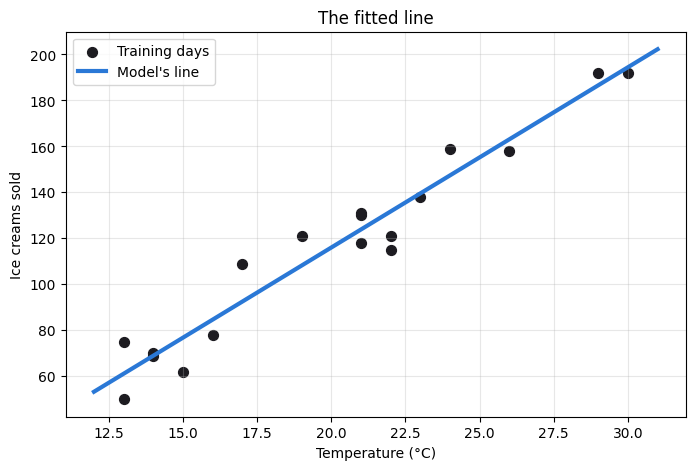

In [8]:
line_temps = pd.DataFrame({"temperature": np.linspace(12, 31, 100)})

plt.scatter(X_train["temperature"], y_train, color=POINT_COLOUR, s=50, label="Training days")
plt.plot(line_temps["temperature"], model.predict(line_temps), color=LINE_COLOUR, linewidth=3,
         label="Model's line")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice creams sold")
plt.title("The fitted line")
plt.legend()
plt.show()

The line runs through the middle of the dots, with some days above it and some below.

## 7. Testing the model on days it has not seen

Now for the real test. We ask the model to predict sales for the 6 hidden test days, and compare its
guesses with what actually happened.

In [9]:
predictions = model.predict(X_test)

results = pd.DataFrame({
    "temperature": X_test["temperature"].values,
    "actual sales": y_test.values,
    "predicted sales": predictions.round(1),
})
results["error (actual - predicted)"] = (results["actual sales"] - results["predicted sales"]).round(1)
results.sort_values("temperature")

,temperature,actual sales,predicted sales,error (actual - predicted)
2,14,49,68.9,-19.9
4,21,124,123.8,0.2
5,23,149,139.5,9.5
1,24,156,147.4,8.6
3,27,189,170.9,18.1
0,29,183,186.6,-3.6


Each **error** is how far the prediction was from reality. A positive error means Sam sold **more**
than predicted (would have run short); a negative error means Sam sold **fewer** (would have had
stock left over).

The predictions are close, but not perfect, which is what we expected from the scatter plot.

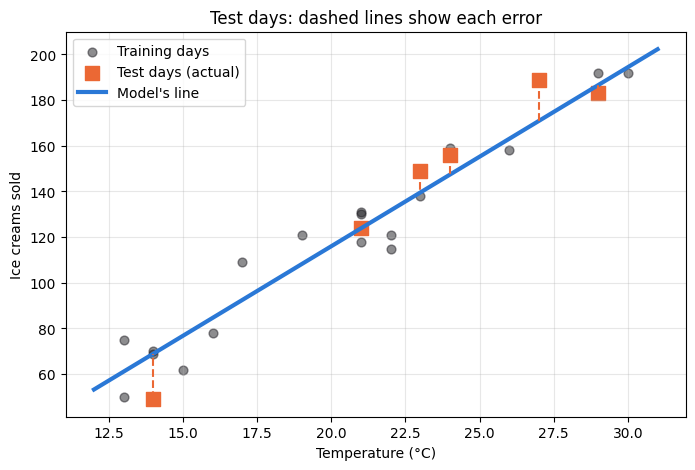

In [10]:
plt.scatter(X_train["temperature"], y_train, color=POINT_COLOUR, s=40, alpha=0.5, label="Training days")
plt.scatter(X_test["temperature"], y_test, color=TEST_COLOUR, s=90, marker="s", label="Test days (actual)")
plt.plot(line_temps["temperature"], model.predict(line_temps), color=LINE_COLOUR, linewidth=3,
         label="Model's line")
# Draw each test error as a vertical line
for t, actual, pred in zip(X_test["temperature"], y_test, predictions):
    plt.plot([t, t], [actual, pred], color=TEST_COLOUR, linestyle="--")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice creams sold")
plt.title("Test days: dashed lines show each error")
plt.legend()
plt.show()

## 8. Measuring how good the model is

Looking at six errors one by one is fine, but we want a few summary numbers. Each one answers a
slightly different question for Sam.

### Mean absolute error (MAE)

*"On a typical day, how far off is the prediction?"* Take each error, ignore whether it is positive or
negative, and average them.

In [11]:
mae = mean_absolute_error(y_test, predictions)
print(f"MAE: {mae:.1f} ice creams")

MAE: 10.0 ice creams


### Root mean squared error (RMSE)

*"How far off are we, with big misses counting extra?"* Square each error (which makes big misses much
bigger), average them, then take the square root to get back to ice creams.

In [12]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"RMSE: {rmse:.1f} ice creams")

RMSE: 12.3 ice creams


RMSE is a little higher than MAE because the errors are not all the same size; RMSE gives more weight
to the larger ones.

### R² (R squared)

*"How much better is this than just guessing the average every day?"* R² is 1 for perfect predictions
and 0 for a model no better than always guessing the average.

In [13]:
r2 = r2_score(y_test, predictions)
print(f"R squared: {r2:.2f}")

R squared: 0.93


### Is that good? Comparing with a simple baseline

A number like "MAE of 10" only means something if we compare it with something. The simplest possible
approach Sam could use, with no model at all, is to load the **average** number sold every day,
whatever the weather.

In [14]:
average_sales = y_train.mean()
baseline_predictions = np.full(len(y_test), average_sales)
baseline_mae = mean_absolute_error(y_test, baseline_predictions)

print(f"Always load the average ({average_sales:.0f} ice creams): MAE = {baseline_mae:.1f}")
print(f"Use the temperature model:                    MAE = {mae:.1f}")

Always load the average (116 ice creams): MAE = 48.0
Use the temperature model:                    MAE = 10.0


**What this means for Sam:** ignoring the weather, Sam would be off by nearly 50 ice creams on a
typical day. Using the forecast temperature, the typical miss drops to about 10. The model is clearly
worth using.

## 9. Answering Sam's question

Tomorrow's forecast is **22°C**. How many ice creams should Sam expect to sell?

In [15]:
tomorrow = pd.DataFrame({"temperature": [22]})
expected = model.predict(tomorrow)[0]

print(f"Forecast 22°C: expect to sell about {expected:.0f} ice creams")
print(f"Typical error (MAE) is about {mae:.0f}, so a sensible range is "
      f"{expected - mae:.0f} to {expected + mae:.0f}")

Forecast 22°C: expect to sell about 132 ice creams
Typical error (MAE) is about 10, so a sensible range is 122 to 142


So Sam should expect to sell about **132 ice creams** tomorrow, and usually somewhere between about
122 and 142. Because running out loses sales, a sensible plan would be to load towards the top of that
range, around 140.

### A warning: don't stretch the line

What if a heatwave hits 40°C, or a cold snap brings 2°C?

In [16]:
for temp in [2, 40]:
    guess = model.predict(pd.DataFrame({"temperature": [temp]}))[0]
    print(f"{temp}°C: the model predicts {guess:.0f} ice creams")

2°C: the model predicts -25 ice creams
40°C: the model predicts 273 ice creams


At 2°C the model predicts a **negative** number of sales, which is impossible. At 40°C it predicts
far more than Sam has ever sold, and it cannot know whether people would even come out in that heat.

Sam's data only covers 13°C to 30°C. Using the model far outside that range is called
**extrapolation**, and its answers should not be trusted. A model only knows about the kind of days
it has seen.

## 10. Summary

| Step | What we did | What it meant for Sam |
|---|---|---|
| Problem | Predict ice creams sold from temperature | Load the right amount of stock |
| Data | 24 days of temperature and sales | Hotter days are clearly busier |
| Split | 18 training days, 6 test days | A fair check on unseen days |
| Model | Straight line: about 7.8 × temperature − 41 | About 8 more sales per extra degree |
| Performance | MAE about 10, RMSE about 12, R² about 0.93 | Typical miss of about 10 ice creams |
| Baseline | Always load the average: MAE about 48 | The model is much better than guessing |
| Prediction | 22°C → about 132 ice creams | Load a little more to avoid selling out |
| Limits | Negative sales at 2°C | Only trust it between about 13°C and 30°C |

The same steps work for any regression problem: understand the question, look at the data, split it,
fit a model, test it on unseen data, compare with a baseline, and explain the answer in the language of
the problem.

## 11. Your turn

1. Tomorrow's forecast is 26°C. How many ice creams should Sam expect to sell?
2. Change `random_state` in section 5 to 1 and rerun the notebook. Do the slope and MAE change much? Why might they change?
3. Add two new days to the data: 18°C with 100 sales, and 28°C with 175 sales. Does the model change?
4. Sam thinks weekends are busier. What extra column would you add to the data to test this, and would it still be a regression problem?
5. In one or two sentences, explain to Sam why the model should not be used for a day of 5°C.